## 3장 1강: 다중 회귀와 규제 모델

### 4. Student Performance 데이터셋 분석
#### 3.1 데이터 준비 및 가공하기

머신러닝 데이터 가공과 시각화에 필요한 필수 도구들을 불러옵니다.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split #train set, validation set, test set 분리
import platform
from matplotlib import rc

os_name = platform.system()

if os_name == 'Windows':
    rc("font", family="Malgun Gothic")
else:
    rc("font", family="AppleGothic")

난수를 고정하여 매번 돌릴 때마다 동일한 분석 결과가 나오도록 처리

In [6]:
np.random.seed(42)

학생 성적(student-por.csv) 불러오기

In [9]:
df = pd.read_csv("student-por.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


분석을 위한 변수 3가지를 독립변수(특성, Feature)로 지정
- studytime: 주당 자습 시간 (1~4 범위)
- freetime: 방과 후 자유 시간 (1~5 범위)
- absences: 학기 중 최종 결석 횟수 (0~93 범위)

In [ ]:
X = df[['studytime', 'freetime', 'absences']]
y = df['G3']

X.head()

,studytime,freetime,absences
0,2,3,4
1,2,3,2
2,2,3,6
3,3,2,0
4,2,3,0


특성 공학(Polynomial Features)을 적용하여 3개의 기본 축을 제곱항과 상호작용항이 포함된 9개 컬럼으로 확장합니다.

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(X)
X_poly = poly.transform(X=X)

X_poly.shape

(649, 9)

In [18]:
feature_names = poly.get_feature_names_out(X.columns)
feature_names

array(['studytime', 'freetime', 'absences', 'studytime^2',
       'studytime freetime', 'studytime absences', 'freetime^2',
       'freetime absences', 'absences^2'], dtype=object)

자습 시간(1~4단계)과 결석 일수(0~93일)의 척도가 크게 다르므로, 이를 동일한 스케일(표준점수)로 맞춰줍니다.

In [21]:
ss = StandardScaler()
X_scaled = ss.fit_transform(X_poly)

X_scaled[:10]

array([[ 0.08365295, -0.17164654,  0.07343336, -0.10972085, -0.02499704,
         0.15793558, -0.33462543,  0.02851214, -0.21578478],
       [ 0.08365295, -0.17164654, -0.35786305, -0.10972085, -0.02499704,
        -0.29661072, -0.33462543, -0.34912826, -0.35282562],
       [ 0.08365295, -0.17164654,  0.50472977, -0.10972085, -0.02499704,
         0.61248188, -0.33462543,  0.40615254,  0.01261663],
       [ 1.29011438, -1.12377133, -0.78915946,  1.21386342, -0.02499704,
        -0.75115702, -1.08921856, -0.72676866, -0.3985059 ],
       [ 0.08365295, -0.17164654, -0.78915946, -0.10972085, -0.02499704,
        -0.75115702, -0.33462543, -0.72676866, -0.3985059 ],
       [ 0.08365295,  0.78047826,  0.50472977, -0.10972085,  0.59896758,
         0.61248188,  0.72180496,  0.78379295,  0.01261663],
       [ 0.08365295,  0.78047826, -0.78915946, -0.10972085,  0.59896758,
        -0.75115702,  0.72180496, -0.72676866, -0.3985059 ],
       [ 0.08365295, -2.07589613, -0.35786305, -0.10972085, -1

#### 3.3 모델 학습 및 시각화

모델 학습 및 규제를 위한 도구를 불러옵니다.

In [28]:
from sklearn.linear_model import Ridge, Lasso


규제 강도(alpha)를 로그 스케일로 0.001부터 1000까지 넓은 범위에 걸쳐 200단계로 나누어 설정합니다.

In [23]:
alphas = np.logspace(-3, 3, 200)

alphas[:10]

array([0.001     , 0.00107189, 0.00114895, 0.00123155, 0.00132009,
       0.00141499, 0.00151672, 0.00162576, 0.00174263, 0.00186791])

모델 학습하기

In [29]:
ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_scaled, y)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=alpha, max_iter=20000, tol=1e-4)
    lasso.fit(X_scaled, y)
    lasso_coefs.append(lasso.coef_)

In [30]:
ridge_coefs[:5]

[array([ 2.24379625,  0.58889643,  0.51051007, -1.04787847, -0.34823071,
        -0.66211807, -0.72031432, -0.10287111, -0.01701943]),
 array([ 2.24378458,  0.58889119,  0.51050615, -1.04787087, -0.34822647,
        -0.66211603, -0.72031189, -0.1028699 , -0.01701855]),
 array([ 2.24377207,  0.58888557,  0.51050195, -1.04786272, -0.34822192,
        -0.66211384, -0.72030929, -0.10286861, -0.01701761]),
 array([ 2.24375866,  0.58887954,  0.51049745, -1.04785398, -0.34821705,
        -0.66211149, -0.72030651, -0.10286723, -0.01701659]),
 array([ 2.24374429,  0.58887308,  0.51049262, -1.04784462, -0.34821183,
        -0.66210898, -0.72030352, -0.10286574, -0.01701551])]

In [31]:
lasso_coefs[:5]

[array([ 2.16648238e+00,  5.15261289e-01,  4.48421227e-01, -1.00659433e+00,
        -3.10897183e-01, -6.40036990e-01, -6.75950460e-01, -7.39144058e-02,
        -1.73073998e-03]),
 array([ 2.16091513e+00,  5.09955822e-01,  4.43952690e-01, -1.00362080e+00,
        -3.08209338e-01, -6.38447740e-01, -6.72752344e-01, -7.18303317e-02,
        -6.30583926e-04]),
 array([ 2.15510976,  0.50433435,  0.43986378, -1.00053144, -0.30533689,
        -0.63692963, -0.66936693, -0.06964424, -0.        ]),
 array([ 2.14899914,  0.49832839,  0.4362979 , -0.99729383, -0.30222624,
        -0.6355149 , -0.66576293, -0.06733119, -0.        ]),
 array([ 2.14245604,  0.49190985,  0.43247979, -0.99382549, -0.29889783,
        -0.63399905, -0.66191436, -0.06485553, -0.        ])]

시각화 하기

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
C:\Users\yangc\AppData\Local\Temp\ipykernel_17720\964831917.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout() # 서브플롯 간의 간격을 자동으로 최적화하여 겹침을 방지
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [

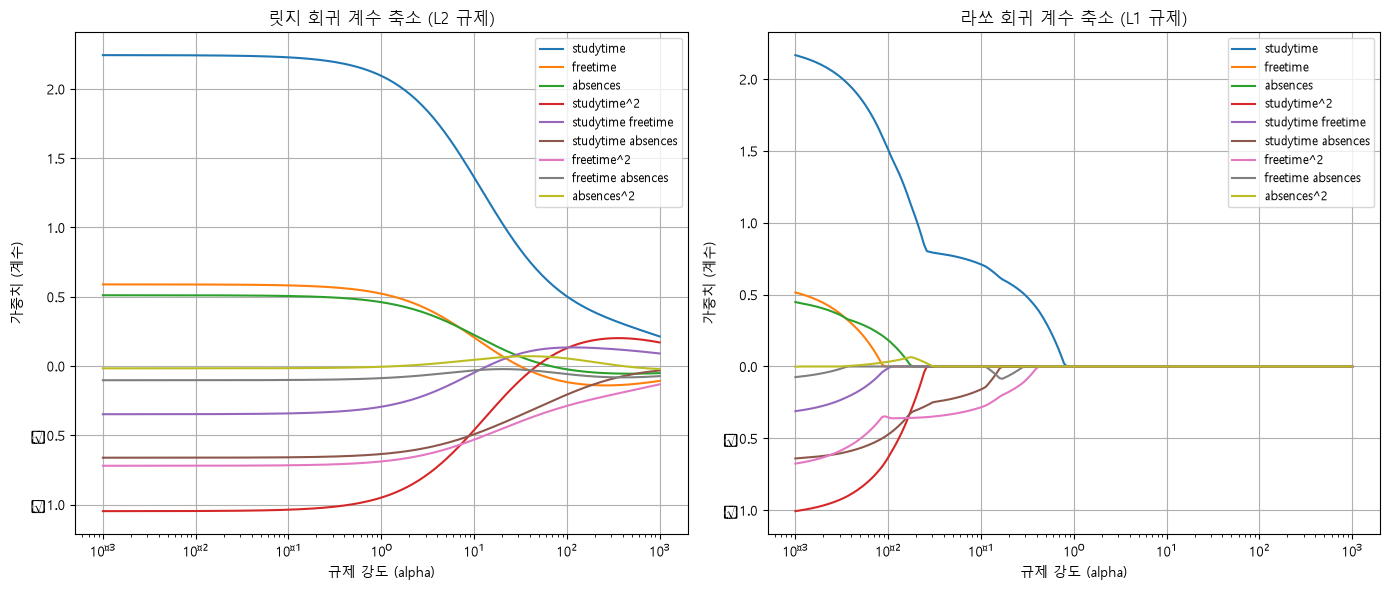

In [34]:
# 데이터 분석 및 시각화를 위해 계수 리스트를 NumPy 배열로 변환합니다.
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

# 두 가지 규제 모델의 가중치 축소 궤적을 비교 시각화하기 위해 1행 2열의 plot 영역을 생성합니다.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽 그래프: 규제가 강해질수록 가중치가 완만하게 0에 가까워지는 릿지(Ridge) 차트
for i in range(X_scaled.shape[1]):
    axes[0].plot(alphas, ridge_coefs[:, i], label=feature_names[i])
axes[0].set_xscale('log') # alpha 값의 광범위한 탐색을 위해 x축을 로그 스케일로 설정
axes[0].set_title('릿지 회귀 계수 축소 (L2 규제)')
axes[0].set_xlabel('규제 강도 (alpha)')
axes[0].set_ylabel('가중치 (계수)')
axes[0].grid(True)
axes[0].legend(fontsize='small', loc='upper right')

# 오른쪽 그래프: 규제가 강해지면서 불필요한 가중치가 완전히 0이 되어 사라지는 라쏘(Lasso) 차트
for i in range(X_scaled.shape[1]):
    axes[1].plot(alphas, lasso_coefs[:, i], label=feature_names[i])
axes[1].set_xscale('log')
axes[1].set_title('라쏘 회귀 계수 축소 (L1 규제)')
axes[1].set_xlabel('규제 강도 (alpha)')
axes[1].set_ylabel('가중치 (계수)')
axes[1].grid(True)
axes[1].legend(fontsize='small', loc='upper right')

plt.tight_layout() # 서브플롯 간의 간격을 자동으로 최적화하여 겹침을 방지
plt.show() # 최종 학습 궤적 시각화 그래프를 화면에 출력합니다.